# 3. Disease context

This notebook takes the embeddings from the modified exitory cells (and their unmodified equivalents) and explores the relative changes in embedding space as a proxy for disease associated differences.
Only the cell embeddings generated previously are considered given the limitations on hardware/time but a more expansive analysis would also consider the cells relative to embeddings for all the other cells in the data set.

The analysis will take the following approach:

- Generate UMAP from embeddings to visualise the local structure of data and any changes induced by the modifications
- Cluster the UMAP and look for co-enrichment of KO/KI cells with unmodified healthy/diseased cells

## Data visualisation

The embeddings are concatenated and a UMAP generated to visualise their relationships in the embedding space.


In [1]:
import scanpy as sc
import pickle
import anndata as ad
import pandas as pd
import scipy.stats
import numpy as np
import re

#load in the data
infile =  open("mod_embed.pkl", 'rb') 
allemb = pickle.load(infile)

In [2]:
#load into an anndata object
adats = []
for i in ["KO","KI"]:
    for j in allemb[i].keys():
        obj = allemb[i][j]
        for k in ["modified","base"]:
            ado = ad.AnnData(X=obj[k])
            ado.obs["Disease"] = obj["params"][1]
            ado.obs["Modification"] = i
            ado.obs["Modified"] = k
            ado.obs["Gene"] = j
            ado.obs_names = i+"_"+k+"_"+j+"_"+ado.obs_names
            adats.append(ado)

adata = ad.concat(adats, axis=0, join="outer")

In [ ]:
## PCA
In the PCA there is not a clear visual seperation of disease and healthy cells on the first 5 PCs.

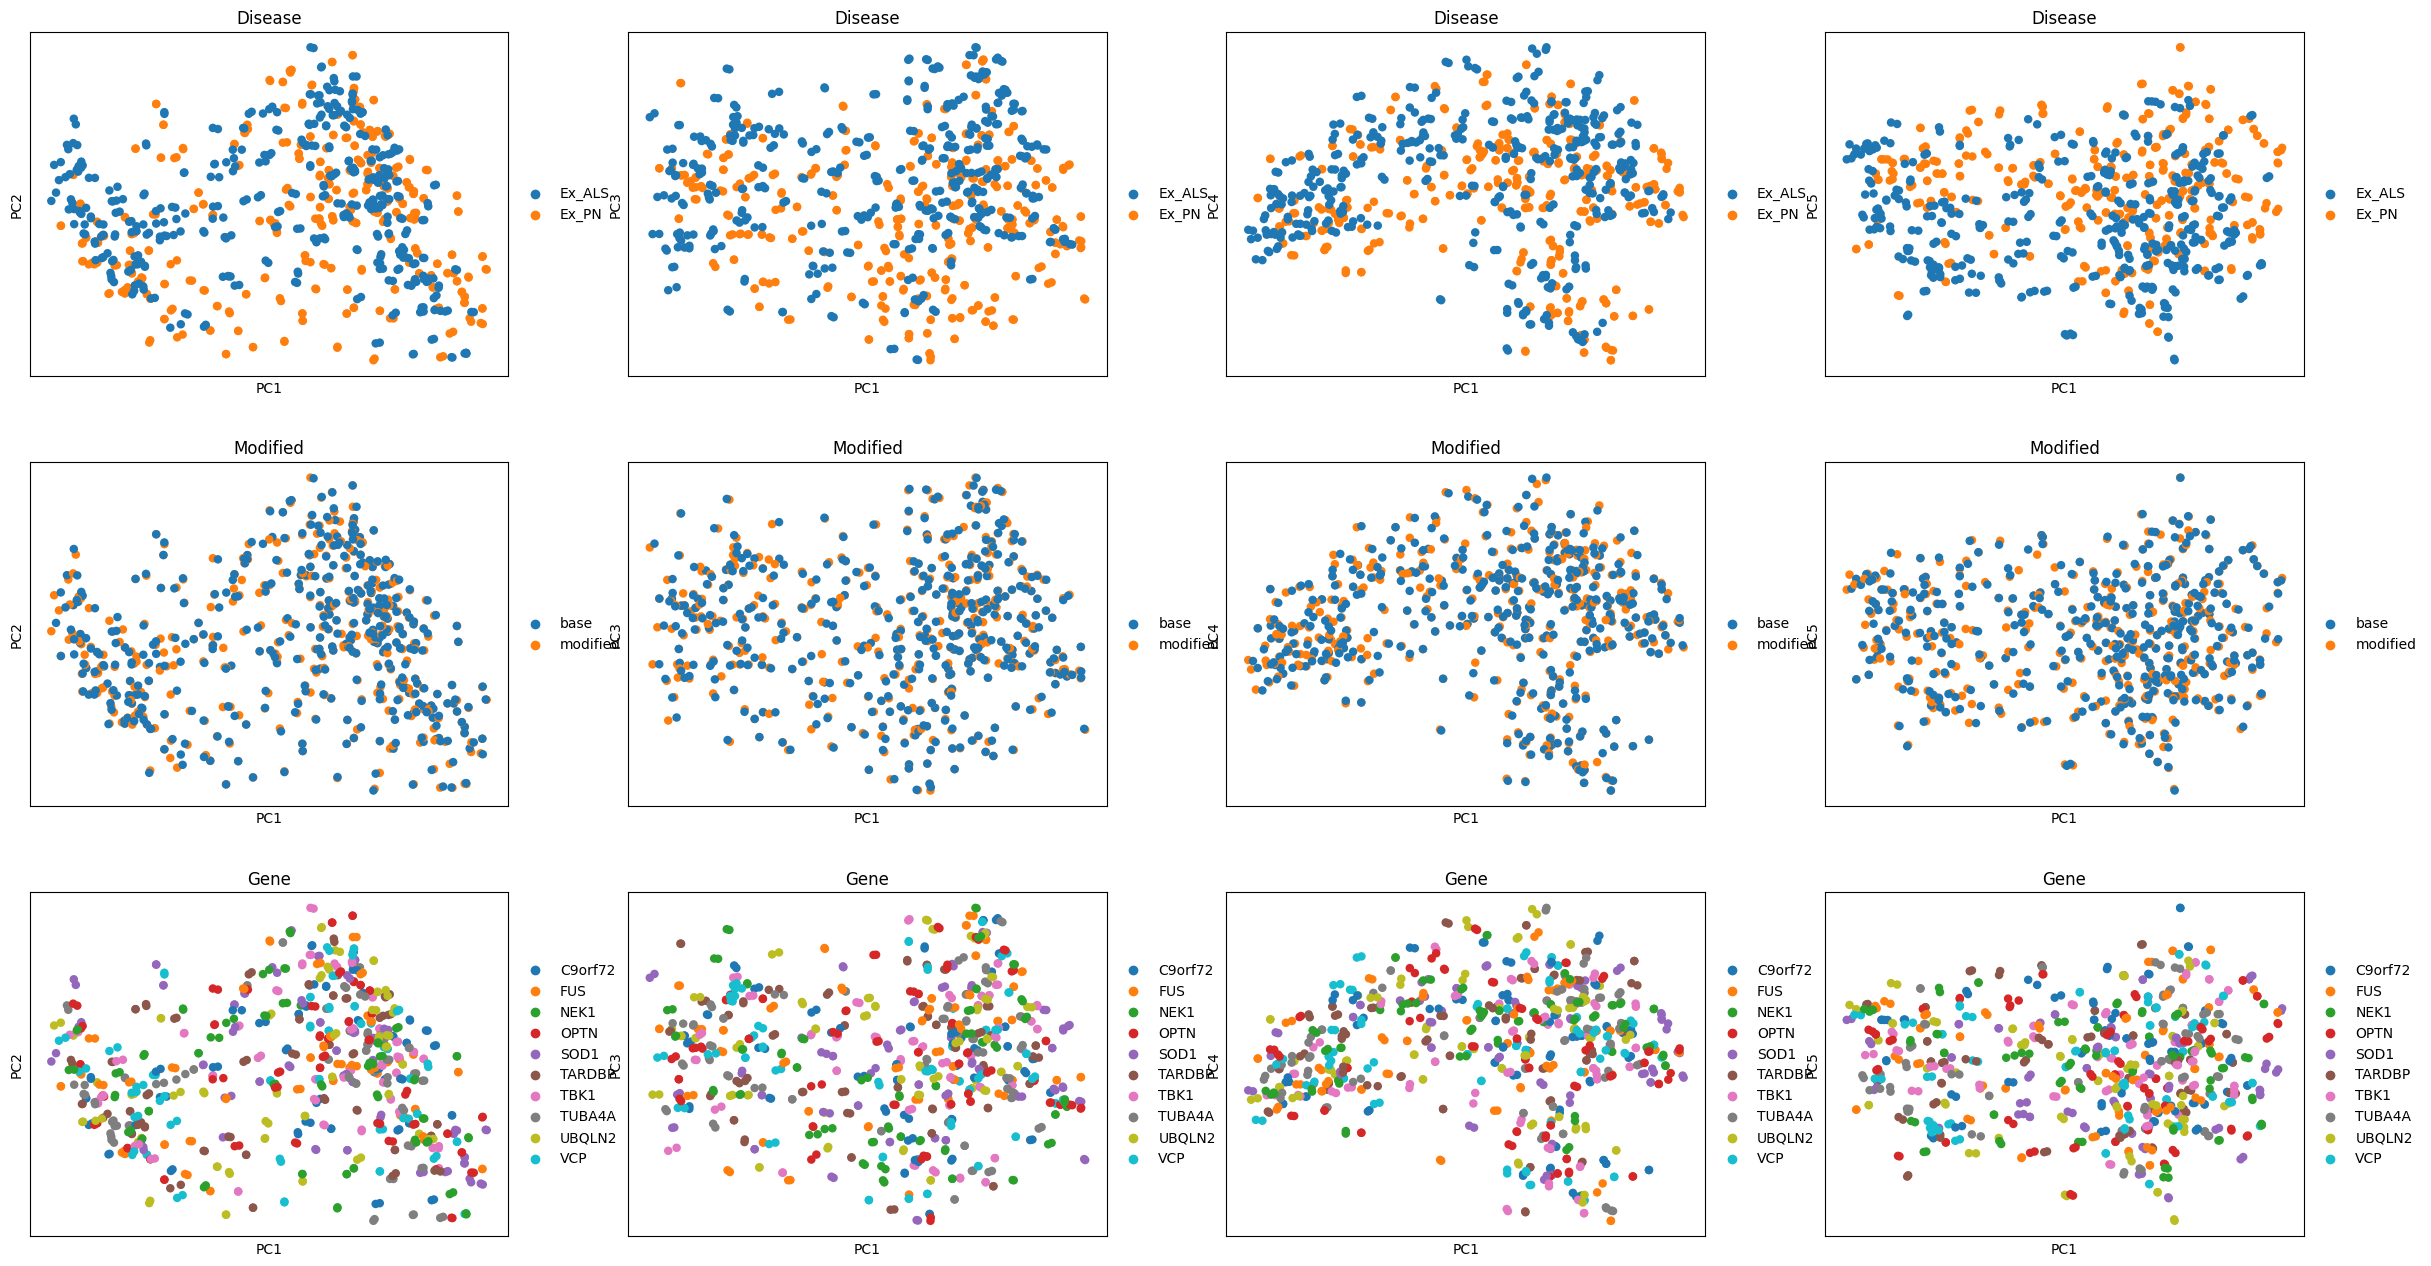

In [14]:
sc.pp.pca(adata)
sc.pl.pca(adata, color=["Disease","Modified","Gene"], components=['1,2', '1,3', '1,4', '1,5'])

## UMAP

UMAP of neighbours from embeddings shows some seperation of excitory cells by disease but there is likely still some cell type/state substructure within the excitory cells that is dominating.
However, subclustering may identify enrichment of specific gene modifications.

In [5]:
#generate umap from the embeddings using scanpy
sc.pp.neighbors(adata, use_rep='X')
sc.tl.umap(adata)

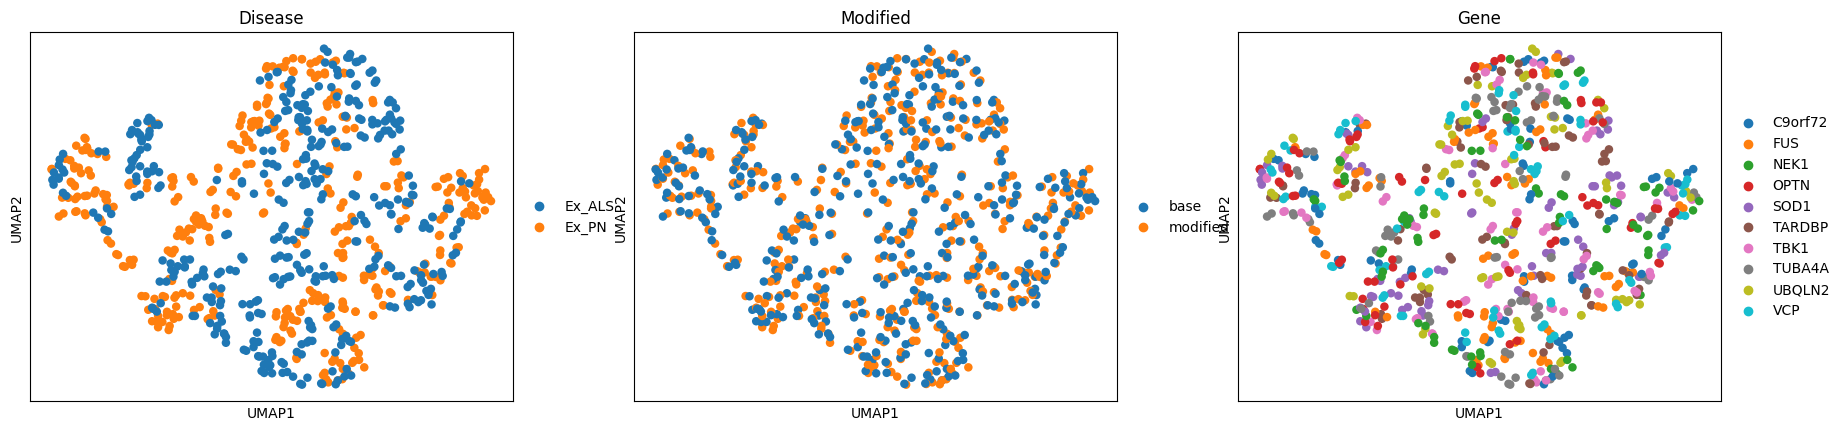

In [16]:
#plot the UMAP
sc.pl.umap(adata, color=["Disease","Modified","Gene"])


# Clustering

Louvain clustering is used to define groups based on the PCs from the PCA of the embeddings.
Enrichment of healthy/diseased cells from base line can then be used to determine if the cluster represents more healthy or diseased signatures.
We can then see if there are any cases where a modification has led to a cell clustering with a different cell set.

In [20]:
#cluster data
sc.tl.leiden(adata)

AnnData object with n_obs × n_vars = 800 × 512
    obs: 'Disease', 'Modification', 'Modified', 'Gene', 'leiden'
    uns: 'pca', 'neighbors', 'umap', 'Disease_colors', 'Modified_colors', 'Gene_colors', 'leiden'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    obsp: 'distances', 'connectivities'

### Cluster UMAP

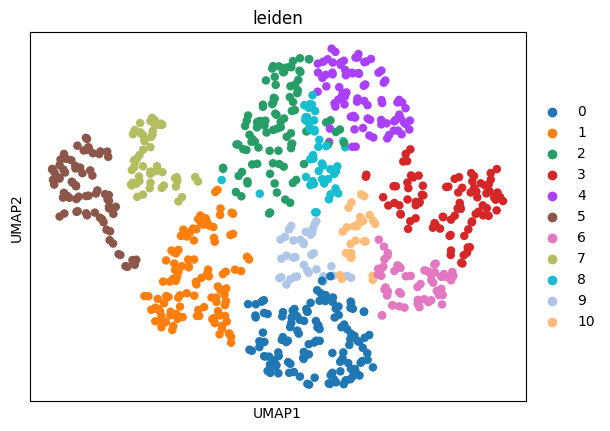

In [21]:
sc.pl.umap(adata, color="leiden")

### Cluster membership
The annotations of unmodified and modfied cells are counted in each cluster to see if there is enrichment of healthy/disease and or any gene modifications.

In [35]:
#split out the base and modified cells
unmod = adata[adata.obs['Modified'] == 'base'].copy()
mod = adata[adata.obs['Modified'] == 'modified'].copy()
ki = mod[mod.obs["Modification"]=="KI"].copy()
ko =  mod[mod.obs["Modification"]=="KO"].copy()

#### Unmodified cells by disease
There arent any clusters of entirely disease or healthy cells when looking at the unmodified cells alone, although some have some significant enrichment (cluster 5 with 70% healthy cells and cluster 8 with ~90% ALS cells). 

Sig enrichment in cluster:  5  pvalue:  0.003500475821755818
Sig enrichment in cluster:  8  pvalue:  0.0006467491225764771


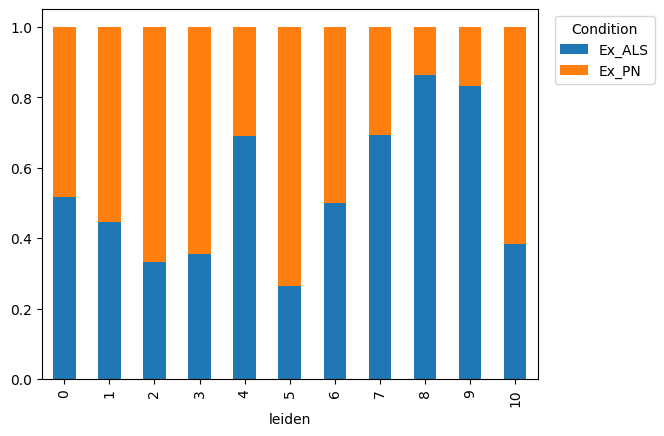

In [80]:
#look at enrichment of diseases across clusters in base data
#plot as percentages
pd.crosstab(unmod.obs['Disease'],unmod.obs['leiden'], normalize='columns').T.plot(kind='bar', stacked=True).legend(title='Condition', bbox_to_anchor=(1.02, 1),loc='upper left')

#get pvals for set enrichment
ct = pd.crosstab(unmod.obs['Disease'],unmod.obs['leiden'])

for cl in ct.columns:
    observed = np.array([ct.loc["Ex_ALS", cl], ct.loc["Ex_PN",  cl]])
    expected = observed.sum()/2
    chi2, p = scipy.stats.chisquare(observed, f_exp=[expected, expected])
    if p < 0.05 / len(ct.columns):
        print("Sig enrichment in cluster: ",cl, " pvalue: ", p)

#### KO cells by gene

There is no signficant enrichment of any genes in any of the clusters by KO.

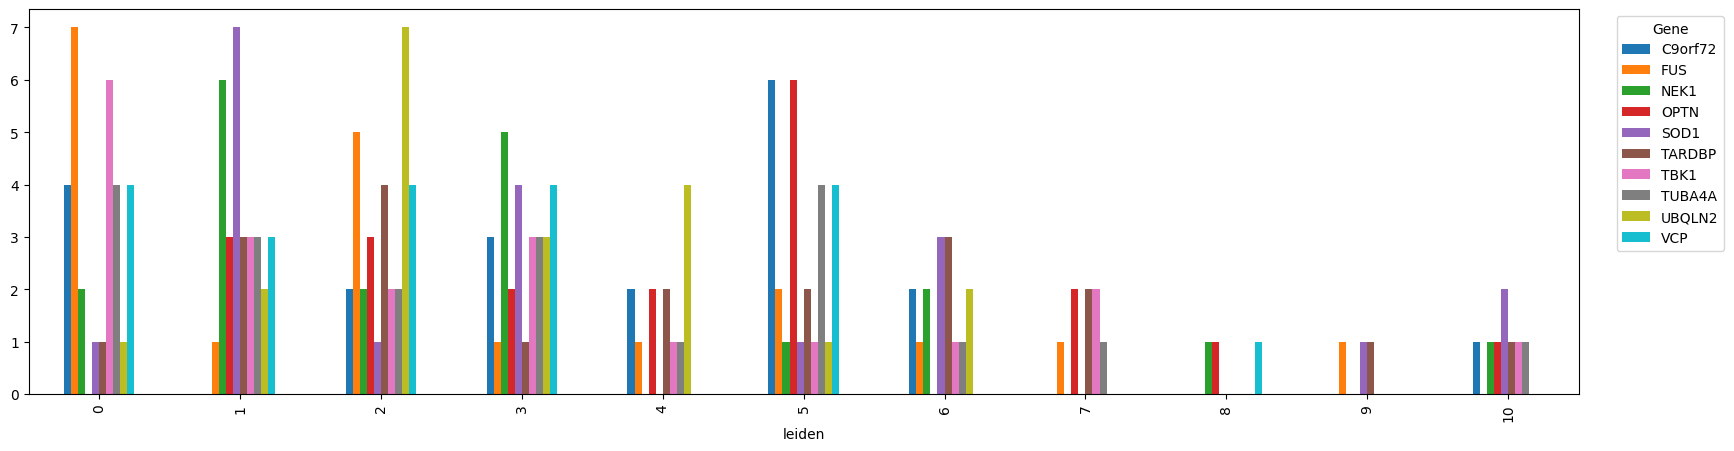

In [116]:
#get pvals for set enrichment
ct = pd.crosstab(ko.obs['Gene'],ko.obs['leiden'])
genes = ko.obs["Gene"].unique()

for cl in ct.columns:
    observed = np.array([ct.loc[x, cl] for x in genes])
    expected = observed.sum()/len(genes)
    chi2, p = scipy.stats.chisquare(observed, f_exp=np.repeat(expected, len(genes)))
    if p < 0.05 / len(ct.columns):
        print("Sig enrichment in cluster: ",cl, " pvalue: ", p)

#look at enrichment of gene ko mods across clusters
ct.T.plot(kind='bar', stacked=False, figsize=(20,5)).legend(title='Gene', bbox_to_anchor=(1.02, 1),loc='upper left')

#### KI cells by gene

There is no signficant enrichment of any genes in any of the clusters by KI.

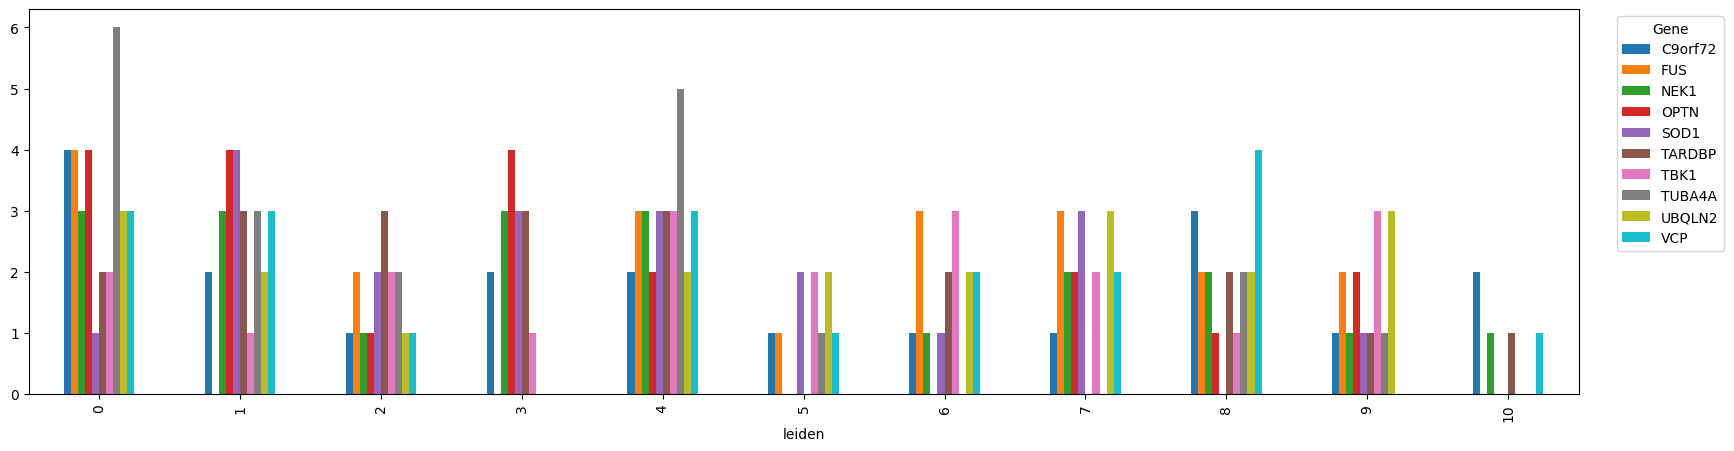

In [115]:
#get pvals for set enrichment
ct = pd.crosstab(ki.obs['Gene'],ki.obs['leiden'])

for cl in ct.columns:
    observed = np.array([ct.loc[x, cl] for x in genes])
    expected = observed.sum()/len(genes)
    chi2, p = scipy.stats.chisquare(observed, f_exp=np.repeat(expected, len(genes)))
    if p < 0.05 / len(ct.columns):
        print("Sig enrichment in cluster: ",cl, " pvalue: ", p)

#look at enrichment of gene ko mods across clusters
ct.T.plot(kind='bar', stacked=False, figsize=(20,5)).legend(title='Gene', bbox_to_anchor=(1.02, 1),loc='upper left')